# LAB 1 Report: Digital Sampling, Fourier Filtering, and Heterodyne Mixers in Radio Astronomy
## ASTRON 121: Radio Astronomy Lab
### Rosendo Medina-Uribe
### February 8, 2026

### Software Package, AI Usage Statement
*This report is supported by a custom, version-controlled Python package. Repository and installation details will be provided upon completion of Goal 8.*

*Throughout the construction of the following plots shown in this report, AI software such as ChatGPT was used to identify and provide solutions to errors that arose in the code itself, such as Syntax errors, or errors involving consistent units or matching array sizes for files that contained non-strucutured data.*

## Introduction

This labratory provided hands-on experience into fundamental concepts that are heavily utilized in Radio Astronomy, such as Digital Sampling, Fourier Analysis, and exploration of mixers. These ideas are further used and explored in future labs in this course, with this lab providing the necessary skills to properly access, read, and shape data to provide necessary visuals.

In this experiment, we primarily used a Raspberry Pi as our main data hub, using an RTL-SDR to collect that data. This equipment was used to investigate and compute Discrete Fourier Transforms (DFTs), along with explorations into Single-sideband (SSB) and Double-sideband (DSB) mixers. The purpose of this lab is outlined in the 8 goals provided at the very beginning of the instructions, which provide the strucutre for this report. Primary concepts involved were Nyquist Sampling, spectral leakage and resolution, noise, and the building/operation of mixers.

Each section will involve on of these concepts discussed above, with a section towards the end of report regarding an installable Python package that can be implemented for future experiment usage.

## Setup and Methods

### Hardware
- **Raspberry Pi 5**: Main data hub, collected data through SDR
- **RTL-SDR** (RTL2832U): Main data collector, connected to Raspberry Pi
- **Signal Generators**: Single one used for Fourier Analysis, two were used for mixer generation
- **Noise Generator**
- **Oscilloscope**: Signal imagery and verification of needed values
- **Mixers**: Up to two were used for DSB and SSB construction
- **Power Splitter/Combiner**: Primarily used for mixer exploration, and other experiements regarding multi-tone usage

### Software
- **Python 3.14** run through Anaconda, containing key packages:
    - ugradio (Ran primarily with Raspberry Pi + SDR)
    - numpy, scipy, matplotlib

- **Git**: Primary code storage/updating software
- **Google Drive**: Primary data storage

### Data Collection Process: 
1. **Signal Generation**: Sine wave and noise generation were create throughtheir respective generators, being verified with an oscilloscpe before collecting data through the SDR.
2. **SDR Sampling**: Signals were sampled using ugradio to operate the SDR, acquiring data with varying sampling frequencies from 1.0-3.0 MHz.
3. **Noise Analysis**: Noise was analyzed to confirm guassian shape, creating visuals to futher investigate properties.
4. **Mixer Experiments**: Local Oscillator (LO) and Radio Frequency (RF) signals were generated and combined through mixers, then collected with SDR.

### Analytical Approach
- Fourier analysis collected using ugradio, analyzed through numpy and matplotlib
- Power spectra, voltage spectra, and other visuals compared to identify patterns.
- Data ranged in both sampling frequency and signal frequency to provide opportunities for further investigation.
- All analysis was conducted in Jupyter notebooks, with reused functions being converted into a single installable Python module.


### Nyquist Sampling and Aliasing

#### Approach
To explore the Nyquist criterion and identify aliasing, a sine wave of 300 kHz was sampled at a rate of 1MHz using the RTL-SDR. Because the sampling frequency $(f_s = 1\ \text{MHz})$ is above the Nyquist Limit for the 300 kHz wave $(2f_0 = 600\ \text{kHz})$, aliasing does not occur. To demonstrate aliasing, a 900 kHz signal is generated, which would be located in the **Second Nyquist Zone**. The 900 kHz was simulated due to lack of time to collect data. According to theory, the $(f_{\text{alias}} = 900\ \text{kHz})$ signal sampled at $(f_s = 1\ \text{MHz})$ will appear at $(f_s - f_{\text{alias}} = 100\ \text{kHz})$ in the first zone. 

#### Code and Visualization
The following code analyzes the data, creates power spectra of the signals, and places them in their respective Nyquist Zones, demonstrating aliasing as needed.

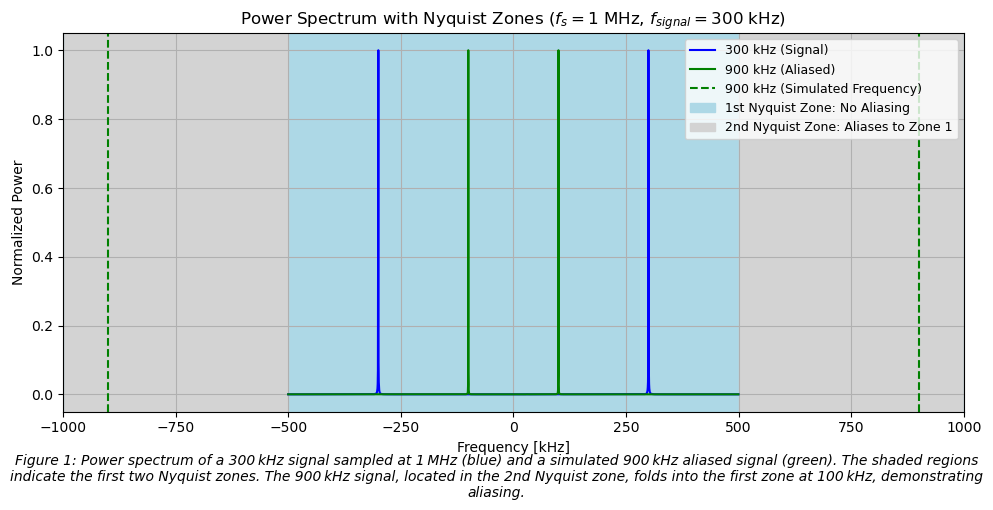

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Load the specific dataset: fs = 1 MHz, f_signal = 300 kHz
data = np.load("C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Nyquist_Sampling/test_1MHz_300kHz.npz")
signal = data["arr_0"][2]  # Using second sample block
signal = signal - np.mean(signal)

# Parameters
fs = 1e6 # Sampling frequency (Hz)
nyquist_freq = fs / 2
true_freq = 300e3 # Signal frequency (Hz)
N = len(signal)

# Simulated aliased frequency (900 kHz, in 2nd Nyquist zone)
f_alias = 900e3
time = np.arange(N) / fs
signal_alias = np.cos(2 * np.pi * f_alias * time)

# Compute power spectra
spectrum = np.fft.fft(signal)
freq = np.fft.fftfreq(N, d = 1/fs)
spectrum_shift = np.fft.fftshift(spectrum)
freqs_shift = np.fft.fftshift(freq)
power = np.abs(spectrum_shift)**2

spectrum_alias = np.fft.fft(signal_alias)
power_alias = np.abs(np.fft.fftshift(spectrum_alias))**2

# Plot
plt.figure(figsize=(10, 5))
plt.plot(freqs_shift/1e3, power / np.max(power), color = 'blue', label = '300 kHz (Signal)')
plt.plot(freqs_shift/1e3, power_alias / np.max(power_alias), color = 'green', label = '900 kHz (Aliased)')

# Mark frequencies
plt.axvline(f_alias/1e3, color = 'green', linestyle = '--', label='900 kHz (Simulated Frequency)')
plt.axvline(-f_alias/1e3, color = 'green', linestyle = '--')

# Shade and label Nyquist zones (using your labeling logic)
for zone in range(1, 4):
    left = (zone - 1) * nyquist_freq
    right = zone * nyquist_freq
    color = 'lightblue' if zone % 2 == 1 else 'lightgray'
    
    if zone == 1:
        label_pos = '1st Nyquist Zone: No Aliasing'
        label_neg = '_nolegend_'
    elif zone == 2:
        label_pos = '2nd Nyquist Zone: Aliases to Zone 1'
        label_neg = '_nolegend_'
    else:
        label_pos = '_nolegend_'
        label_neg = '_nolegend_'
    
    plt.axvspan(left/1e3, right/1e3, color = color, label = label_pos)
    plt.axvspan(-right/1e3, -left/1e3, color = color, label = label_neg)

plt.xlabel('Frequency [kHz]')
plt.ylabel('Normalized Power')
plt.title(r'Power Spectrum with Nyquist Zones ($f_s = 1$ MHz, $f_{signal} = 300$ kHz)')
plt.legend(fontsize = 9)
plt.xlim(-1000, 1000)
plt.grid()
plt.tight_layout()

plt.figtext(0.5, -0.05, 
            "Figure 1: Power spectrum of a 300 kHz signal sampled at 1 MHz (blue) and a simulated 900 kHz aliased signal (green). " +
            "The shaded regions indicate the first two Nyquist zones. " +
            "The 900 kHz signal, located in the 2nd Nyquist zone, folds into the first zone at 100 kHz, demonstrating aliasing.",
            ha='center', fontsize = 10, wrap = True, style = "italic")

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to make room for caption
plt.show()

#### Interpretation
This plot shows two power spectra:
- **Blue Curve**: The 300 kHz signal that was collected shows up in the **First Nyquist Zone**, which ranges from -500 kHz to +500 kHz.
- **Green Curve**: The simulated 900 kHz, which lies in the **Second Nyquist Zone** (As shown with the dotted green line), folds back into the first zone to 100kHz. This direclty demonstrates aliasing in action.

The shaded zones are organized to show the following pattern: odd-numbered zones are plotted directly, which even numbered zones are mirrored back into the first zone.

#### Qualitative Check
Looking into the aliasing formula:

$f_{\text{observed}} = |f_{\text{signal}} - k f_s|, \quad k \in \mathbb{Z}$

For $(f_{\text{signal}} = 900\ \text{kHz})$ and $(f_s = 1\ \text{MHz})$, the smallest alias occurs with (k=1):

$f_{\text{alias}} = |900\ \text{kHz} - 1 \times 1000\ \text{kHz}| = 100\ \text{kHz}$

The green curve appears right on at $\pm$ 100kHz, confirming the prediction.

#### Interpretation
This visual, and the experiment, confirms the Nyquist criterion: To avoid aliasing, a signal must be sampled at more than twice its signal frequency. Signals in higher Nyquist Zones are folded back into the first zone, which produces low-frequency signals that have been heavily aliased. These findings help to show the importance of setting proper parameters to collect the best-quality data possible.

### Characterizing the Bandpass Filter of the SDR

#### Approach
Inside the RTL-SDR is an anti-aliasing filter, limiting the input bandwidth and decrasing it to less than that of the original sampling frequency. To see this filter, a signal wave of constant amplitude was generated at different frequencies from 50-500 kHz in incraments of 50kHz. The signals were then sampled at 5 different sampling frequencies (1, 1.5, 2, 2.5, and 3 MHz) with the SDR. From each frequency, the peak Fourier domain was extracted and normalized to reveal the filter's response to frequency. The code below shows this plot of maximum domains for each frequency.

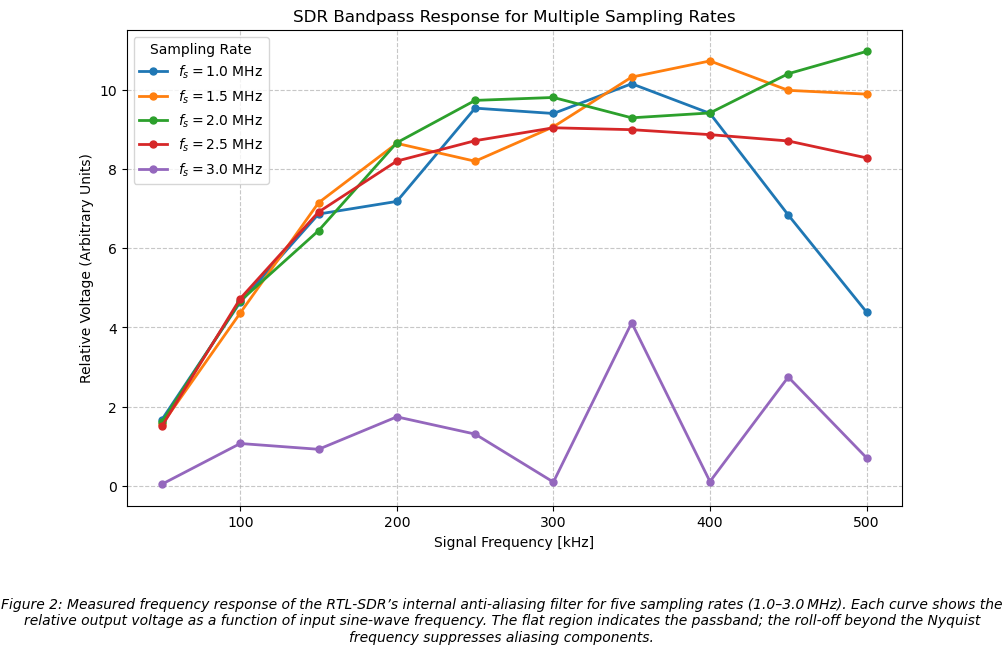

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

base_dir = Path("C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter")

sampling_rates = np.array([1e6, 1.5e6, 2e6, 2.5e6, 3e6])
signal_freqs = np.array([50e3, 100e3, 150e3, 200e3, 250e3, 300e3, 350e3, 400e3, 450e3, 500e3])

# Organize file paths by sampling rate
files_by_fs = {
    fs: [
        base_dir / f"{fs/1e6:g}MHz_Sampling" / f"test_{fs/1e6:g}MHz_{int(f/1e3)}kHz.npz"
        for f in signal_freqs
    ]
    for fs in sampling_rates
}

def extract_peak_magnitude(filename, fs, f_sig, N = 2048):
    """
    Extract the average FFT peak magnitude at f_sig from an SDR data file.
    
    Parameters:
        filename : Path
            Path to .npz file (expects data in 'arr_0')
        fs : float
            Sampling frequency (Hz)
        f_sig : float
            Signal frequency (Hz)
        N : int
            Number of samples to use per block (default 2048)
    
    Returns:
        peak_mag : float
            Average FFT magnitude at the signal frequency across all blocks
    """
    data = np.load(filename)['arr_0']  # shape: (num_blocks, samples_per_block)
    signal = data[:, :N] # trim each block to N samples
    
    window = np.hanning(N)
    signal_win = signal * window
    
    spectrum_mag = np.abs(np.fft.fft(signal_win, axis=1))
    freqs = np.fft.fftfreq(N, d=1/fs)
    idx = np.argmin(np.abs(freqs - f_sig))
    peak_mag = np.mean(spectrum_mag[:, idx])

    return peak_mag

# Plot the filter response for each sampling rate
plt.figure(figsize = (10, 7))

for fs in sampling_rates:
    magnitudes = []
    files = files_by_fs[fs]
    for f_sig, fname in zip(signal_freqs, files):
        peak_mag = extract_peak_magnitude(fname, fs, f_sig, N = 2048)
        magnitudes.append(peak_mag)
    
    # Convert FFT magnitude to approximate voltage (scale factor from window and FFT normalization)
    fft_mag_volts = (np.array(magnitudes) / 2048) * 2
    plt.plot(signal_freqs / 1e3, fft_mag_volts, 'o-', linewidth=2, markersize = 5, label = f'$f_s = {fs/1e6}$ MHz')

plt.xlabel("Signal Frequency [kHz]")
plt.ylabel("Relative Voltage (Arbitrary Units)")
plt.title("SDR Bandpass Response for Multiple Sampling Rates")
plt.grid(True, linestyle = '--', alpha = 0.7)
plt.legend(title="Sampling Rate")

caption_text = (
    "Figure 2: Measured frequency response of the RTL‑SDR’s internal anti‑aliasing filter "
    "for five sampling rates (1.0–3.0 MHz). Each curve shows the relative output voltage "
    "as a function of input sine‑wave frequency. The flat region indicates the passband; "
    "the roll‑off beyond the Nyquist frequency suppresses aliasing components."
)
plt.figtext(0.5, 0.01, caption_text, ha = 'center', fontsize = 10, wrap = True, style = 'italic')

plt.subplots_adjust(bottom = 0.2)
plt.show()

#### Results
**Key Observations**

- For each sampling rate, the response from the SDR is roughly constant up to around $0.4 f_s$, then begins to roll-off.
- The point of -3dB seems to show at around $f_s/2$, which confirms the role of the filter in enforcing the Nyquist criterion.
- As sampling rates increase, the passband proprtionality discussed is extended, which is expected for a filter designed fixed relative to $f_s$.

#### Discussion
The SDR's filter is designed to reduce the input bandwidth of the signal in order to reduce the effect aliasing has on signals found at higher nyquist zones. The gradual roll-off seen seems to follow that of simple FIR filters found in SDRs like the ones used for this lab. Future investigation should include frequencies higher than 500 kHz to demonstrate the SDRs filter more for samples higher than 1MHz. It may also be beneficial to investigate the discrepency shown between the 3MHz sampling rate with other sampling rates, and document a possible divide among the sampling frequencies.
